In [ ]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
mnist = fetch_openml('mnist_784', version=1, cache=True) #28*28

In [ ]:
X = mnist.data.to_numpy()

In [ ]:
y = mnist.target.astype(int).to_numpy()

In [ ]:
X = X[(y == 0) | (y == 1)]
y = y[(y == 0) | (y == 1)]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train = X_train[:5000]
y_train = y_train[:5000]

In [ ]:
clf = svm.SVC(kernel='linear', C=5)
clf.fit(X_train, y_train)

SVC(C=5, kernel='linear')

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9986468200270636


Prediction: 0


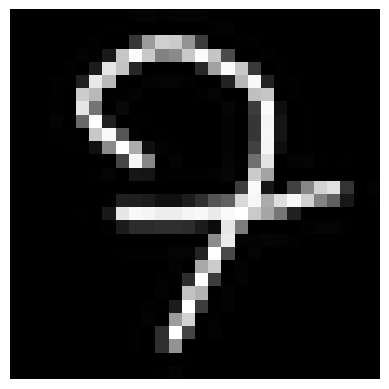

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
def preprocess_image(image_path, target_size=(28, 28)):
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize(target_size, Image.LANCZOS)
    # Invert and ensure correct data type (important fix!)
    img_array = 255 - np.array(img).astype(np.float32)  # Convert to float before inverting
    img = Image.fromarray(img_array).convert('L') # Convert to grayscale again after inversion
    img_array = np.array(img).flatten()
    plt.imshow(img, cmap=plt.cm.gray)
    plt.axis('off')
    return img_array

# Example usage:
image_path = "/content/my_image.png"
processed_image = preprocess_image(image_path)

prediction = clf.predict(processed_image.reshape(1, -1)) # Reshape is important here
print(f"Prediction: {prediction[0]}")

In [ ]:
support_vector_indices = clf.support_
support_vectors = X_train[support_vector_indices]
support_vector_labels = y_train[support_vector_indices]

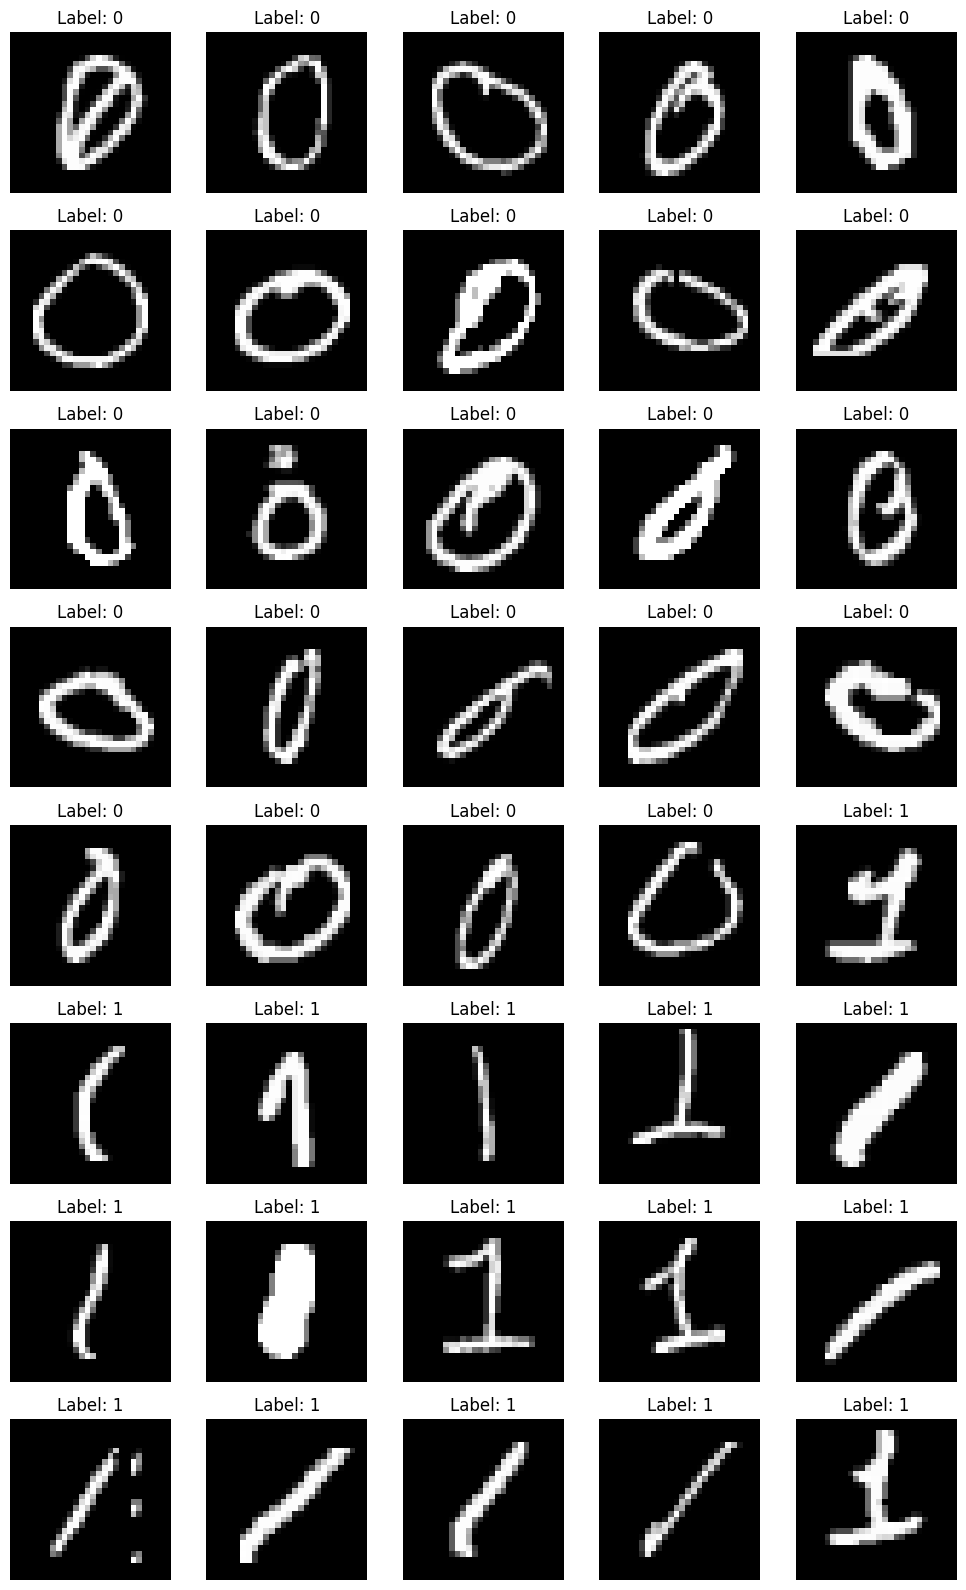

In [ ]:
num_sv_to_display = len(support_vectors)
nrows = int(np.ceil(num_sv_to_display / 5))
fig, axes = plt.subplots(nrows, 5, figsize=(10, 2 * nrows))

for i, ax in enumerate(axes.flat):
    if i < num_sv_to_display:
        image = support_vectors[i].reshape(28, 28)
        ax.imshow(image, cmap=plt.cm.gray)
        ax.set_title(f"Label: {support_vector_labels[i]}")
        ax.axis('off')
    else:
        fig.delaxes(ax)  # Remove unused axes

plt.tight_layout()
plt.show()